<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# EPC Dataset Analysis Using PCA for Archetype Energy Demand and Carbon Emission

## Practical Applications

* **Targeted Retrofit:** Use PC1 and PC2 to identify high-priority properties and match them with appropriate energy-efficiency upgrades.
* **Social Housing Management:** Group properties into PCA-based archetypes to support cost-effective retrofit planning and compliance monitoring.
* **Green Finance:** Use PC1 as a **climate transition risk indicator** for mortgage lending, investment, and ESG assessments.
* **Energy Planning:** Use PCA profiles to identify areas suitable for **district heating and electricity-grid upgrades**.
* **Property Analytics:** Use principal components to reduce multicollinearity and improve **property valuation, rental, and retrofit-cost models**.

### Key Limitations

* **Mixed data types:** Standard PCA is not ideal for combining continuous and categorical variables; **FAMD** may be more appropriate.
* **Ordinal assumptions:** EPC ratings and construction age bands are converted to numerical values, assuming relationships that may not be fully linear.
* **Missing data:** `dropna()` reduces the sample and may introduce **selection bias** if missingness is systematic.
* **Outliers and skewness:** Large properties and high emissions can disproportionately influence PCA despite standardisation.
* **Non-linear relationships:** PCA may miss complex non-linear relationships between building characteristics and energy performance.
* **Limited generalisability:** Results are based on **Sheffield** and may not directly represent wider UK housing stock.
* **EPC limitations:** EPC ratings represent theoretical building performance and may not reflect **actual household energy use or occupant behaviour**.


## Pipelines
### Step 1: Data Selection and Scope

* Selected **nine EPC variables** representing key property and energy characteristics:

  * `total_floor_area`
  * `co2_emissions_current`
  * `energy_consumption_current`
  * `current_energy_efficiency`
  * `current_energy_rating`
  * `construction_age_band`
  * `tenure`
  * `property_type`
  * `built_form`
* Variables were grouped into:

  * **Quantitative:** energy consumption, CO₂ emissions, floor area, and energy efficiency.
  * **Ordinal:** energy rating and construction age.
  * **Nominal:** tenure, property type, and built form.

### Step 2: Data Cleaning and Standardisation

* Removed leading and trailing whitespace from string variables.
* Standardised `tenure` values to lowercase to ensure consistent category labels.
* Converted uninformative values such as:

  * `nan`
  * `unknown`
  * `Not Recorded`
    into explicit missing values (`NaN`).
* This reduced inconsistencies and ensured that equivalent categories were treated consistently.

### Step 3: Ordinal Feature Engineering

* Converted EPC energy ratings into an ordinal numerical scale:

  * `A = 7`
  * `B = 6`
  * `C = 5`
  * `D = 4`
  * `E = 3`
  * `F = 2`
  * `G = 1`
* Converted construction age bands into representative midpoint years.

  * For example, `1900–1929` was represented by **1915**.
* Created two numerical variables:

  * `energy_rating_num`
  * `construction_year_num`
* The original categorical versions were removed after transformation.

#### Step 3.1: Missing Value Treatment

* Missing values were handled **after ordinal transformation**.
* Rows containing missing values in the variables required for PCA were removed using `dropna()`.
* This ensured that the PCA input matrices contained no missing values.
* Two complete-case datasets were produced:

  * **Pipeline A:** 187,222 observations.
  * **Pipeline B:** 175,145 observations.

### Step 4: Pipeline A – Quantitative and Ordinal PCA

* Selected six numerical/ordinal variables:

  * Floor area
  * CO₂ emissions
  * Energy consumption
  * Current energy efficiency
  * Energy rating
  * Construction year
* Standardised all variables using **Z-score standardisation**.
* Standardisation ensured that variables measured in different units contributed comparably to the PCA.
* A full PCA was then fitted to the six standardised variables.
* Six principal components were generated.

#### Step 4.1: Interpretation of Pipeline A

* **PC1 – Energy Inefficiency and Carbon Intensity**

  * Explained **61.89%** of total variance.
  * Represents the dominant energy-performance dimension.
* **PC2 – Property Scale and Unit Intensity**

  * Explained **21.14%** of variance.
  * Represents variation between physical property size and energy intensity.
* **PC3 – Construction Vintage**

  * Explained **10.84%** of variance.
  * Captures differences associated with property construction age.
* The first three components together explained **93.87%** of total variance.

### Step 5: Pipeline B – Categorical and PCA Integration

* Included the nominal variables:

  * `tenure`
  * `property_type`
  * `built_form`
* Applied **one-hot encoding** to convert categorical variables into binary indicators.
* Used `drop_first=True` to reduce redundant dummy variables and avoid perfect multicollinearity.
* The resulting dataset contained **16 encoded features**.
* All features were standardised before PCA.
* Ten principal components were extracted.
* These components collectively explained **93.42% of the total variance**.

#### Step 5.1: PCA Evaluation

* **Scree plots** were used to examine the decline in eigenvalues across components.
* **Cumulative variance plots** were used to assess how many components were required to represent the majority of information.
* **Factor-loading heatmaps** were generated to identify which original variables contributed most strongly to each principal component.
* These analyses provided the basis for interpreting and labelling the latent dimensions.

#### Step 5.2: Subgroup Profiling

* PCA scores were linked back to housing characteristics to investigate differences between property groups.
* **Tenure analysis:**

  * Social housing had the lowest mean PC1 score (**−1.099**).
  * Private owner-occupied properties had a positive mean PC1 score (**+0.514**).
  * This indicates substantial variation in the dominant energy-performance dimension across tenure groups.
* **Property-type analysis:**

  * Flats showed a strongly negative PC1 score (**−1.251**) and positive PC2 score (**+0.476**).
  * Detached properties showed a positive PC1 score (**+0.457**) and negative PC2 score (**−0.845**).
* These patterns indicate differences in **property scale, energy intensity, and overall energy-performance characteristics** between property types.

### Step 6: Overall Analytical Outcome

* PCA reduced a complex set of EPC variables into a smaller number of interpretable latent dimensions.
* **Pipeline A** primarily captured relationships between **energy performance, emissions, property size, and construction age**.
* **Pipeline B** extended the analysis to include **tenure, property type, and built form**.
* The results demonstrate that EPC characteristics are strongly structured around:

  * **Energy inefficiency and carbon intensity**
  * **Physical property scale and energy intensity**
  * **Construction vintage**
  * **Housing structure and tenure**
* The PCA outputs therefore provide a compact framework for **comparing energy-performance patterns across different residential property groups**.

### Step 7. Energy Inefficiency & Emissions vs Property Scale (PC1) vs Energy Intensity Key Results (PC2) 

* **PC1 – Energy Inefficiency & Emissions**

  * **PC1 > 2.0:** Represents properties with **lower energy efficiency, lower SAP scores, and higher CO₂ emissions**.
  * **PC1 < −2.0:** Represents **highly energy-efficient properties**, generally associated with more modern construction.

* **PC2 – Property Scale vs Energy Intensity**

  * **Negative PC2:** Associated with **larger properties**, particularly detached and semi-detached houses, driven strongly by `total_floor_area`.
  * **Positive PC2:** Associated with **smaller, more compact properties**, particularly flats and maisonettes, characterised by higher energy consumption per unit area.

* **Overall Interpretation**

  * **PC1 primarily captures energy-performance differences**, ranging from efficient to inefficient properties.
  * **PC2 captures the contrast between physical property size and relative energy intensity**.
  * Together, PC1 and PC2 provide a clear two-dimensional representation of **energy efficiency, emissions, property scale, and unit-level energy intensity**.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# ==============================================================================
# 1. LOAD DATASET & DEFINE TARGET FEATURES
# ==============================================================================
file_path = 'EPC_Sheffield_20260414-clean.csv'
df = pd.read_csv(file_path)

features = [
    'co2_emissions_current',
    'energy_consumption_current',
    'total_floor_area',
    'current_energy_efficiency',
    'current_energy_rating',
    'tenure',
    'property_type',
    'construction_age_band',
    'built_form',
]

df_clean = df[features].copy()

In [3]:
# ==============================================================================
# 2. STRING CLEANING & CATEGORICAL STANDARDIZATION
# ==============================================================================
# Clean string casing and convert 'nan' / 'unknown' to np.nan
df_clean['tenure'] = df_clean['tenure'].astype(str).str.lower().str.strip()
df_clean['tenure'] = df_clean['tenure'].replace({'nan': np.nan, 'unknown': np.nan})

df_clean['property_type'] = df_clean['property_type'].astype(str).str.strip()
df_clean.loc[df_clean['property_type'] == 'nan', 'property_type'] = np.nan

df_clean['built_form'] = df_clean['built_form'].astype(str).str.strip()
df_clean.loc[
    df_clean['built_form'].isin(['nan', 'Not Recorded']), 'built_form'
] = np.nan


In [4]:
# ==============================================================================
# 3. ORDINAL MAPPER DICTIONARIES
# ==============================================================================
rating_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}

age_map = {
    'England and Wales: before 1900': 1890,
    'England and Wales: 1900-1929': 1915,
    'England and Wales: 1930-1949': 1940,
    'England and Wales: 1950-1966': 1958,
    'England and Wales: 1967-1975': 1971,
    'England and Wales: 1976-1982': 1979,
    'England and Wales: 1983-1990': 1986,
    'England and Wales: 1991-1995': 1993,
    'England and Wales: 1996-2002': 1999,
    'England and Wales: 2003-2006': 2004,
    'England and Wales: 2007-2011': 2009,
    'England and Wales: 2007 onwards': 2009,
    'England and Wales: 2012 onwards': 2016,
    'England and Wales: 2012-2021': 2016,
    'England and Wales: 2022 onwards': 2023,
}

df_clean['energy_rating_num'] = df_clean['current_energy_rating'].map(
    rating_map
)
df_clean['construction_year_num'] = df_clean['construction_age_band'].map(
    age_map
)

# Drop original categorical columns mapped to numeric representations
df_clean.drop(
    columns=['current_energy_rating', 'construction_age_band'], inplace=True
)

In [5]:
# ==============================================================================
# 4. METHOD 1: PCA ON NUMERIC & ORDINAL FEATURES ONLY
# ==============================================================================
num_vars = [
    'total_floor_area',
    'co2_emissions_current',
    'energy_consumption_current',
    'current_energy_efficiency',
    'energy_rating_num',
    'construction_year_num',
]

df_num_pca = df_clean[num_vars].dropna().copy()

scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(df_num_pca)

pca_num = PCA()
X_num_pca = pca_num.fit_transform(X_num_scaled)

loadings_num = pd.DataFrame(
    pca_num.components_.T,
    index=num_vars,
    columns=[f'PC{i+1}' for i in range(len(num_vars))],
)

print('=== METHOD 1: NUMERIC & ORDINAL PCA RESULTS ===')
print(f'Sample Size: {len(df_num_pca)}')
print('Explained Variance Ratio:', pca_num.explained_variance_ratio_.round(4))
print(
    'Cumulative Variance:', np.cumsum(pca_num.explained_variance_ratio_).round(4)
)
print('\nComponent Loadings:')
print(loadings_num.round(4))
print('\n' + '=' * 60 + '\n')

=== METHOD 1: NUMERIC & ORDINAL PCA RESULTS ===
Sample Size: 187222
Explained Variance Ratio: [0.6189 0.2114 0.1084 0.0402 0.0132 0.0079]
Cumulative Variance: [0.6189 0.8303 0.9387 0.9789 0.9921 1.    ]

Component Loadings:
                               PC1     PC2     PC3     PC4     PC5     PC6
total_floor_area           -0.2349  0.7762  0.0933  0.0756 -0.5094 -0.2616
co2_emissions_current      -0.4451  0.3950  0.1715  0.1553  0.6498  0.4124
energy_consumption_current -0.4103 -0.4026  0.2269  0.7313 -0.2873  0.0258
current_energy_efficiency   0.4890  0.1968 -0.1314  0.2854 -0.2854  0.7362
energy_rating_num           0.4731  0.2017 -0.1317  0.5880  0.3924 -0.4674
construction_year_num       0.3397  0.0038  0.9358 -0.0905  0.0165 -0.0181




In [6]:
# ==============================================================================
# 5. METHOD 2: PCA ON FULL ENCODED FEATURE SET (ONE-HOT ENCODING)
# ==============================================================================
# Drop missing values AFTER mapping all ordinal values to avoid post-drop NaNs
df_full_pca = df_clean.dropna().copy()

cat_cols = ['tenure', 'property_type', 'built_form']
df_encoded = pd.get_dummies(df_full_pca, columns=cat_cols, drop_first=True)

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(df_encoded)

pca_full = PCA(n_components=10)
X_full_pca = pca_full.fit_transform(X_full_scaled)

loadings_full = pd.DataFrame(
    pca_full.components_[:5].T,
    index=df_encoded.columns,
    columns=[f'PC{i+1}' for i in range(5)],
)

print('=== METHOD 2: FULL FEATURE SET PCA RESULTS (ONE-HOT ENCODED) ===')
print(f'Sample Size: {len(df_encoded)}')
print(
    'Explained Variance Ratio (First 10 PCs):',
    pca_full.explained_variance_ratio_.round(4),
)
print(
    'Cumulative Variance Ratio:',
    np.cumsum(pca_full.explained_variance_ratio_).round(4),
)
print('\nTop 5 Loadings:')
print(loadings_full.round(4))

=== METHOD 2: FULL FEATURE SET PCA RESULTS (ONE-HOT ENCODED) ===
Sample Size: 175145
Explained Variance Ratio (First 10 PCs): [0.2755 0.1237 0.0946 0.0846 0.075  0.0679 0.0637 0.058  0.053  0.0382]
Cumulative Variance Ratio: [0.2755 0.3992 0.4938 0.5784 0.6534 0.7213 0.785  0.843  0.896  0.9342]

Top 5 Loadings:
                                    PC1     PC2     PC3     PC4     PC5
co2_emissions_current           -0.4012  0.0082 -0.0003  0.0330  0.2570
energy_consumption_current      -0.3161  0.3636 -0.2427  0.0771 -0.2049
total_floor_area                -0.2503 -0.2630  0.1646 -0.0344  0.4825
current_energy_efficiency        0.4177 -0.2244  0.1580 -0.0931  0.1316
energy_rating_num                0.4056 -0.2092  0.1590 -0.0944  0.1408
construction_year_num            0.3143 -0.0920 -0.1775 -0.0344  0.1141
tenure_rented (private)          0.0044  0.3266  0.0354 -0.4495  0.2686
tenure_rented (social)           0.2173 -0.0334  0.0360  0.4953 -0.2741
property_type_Flat               0.282

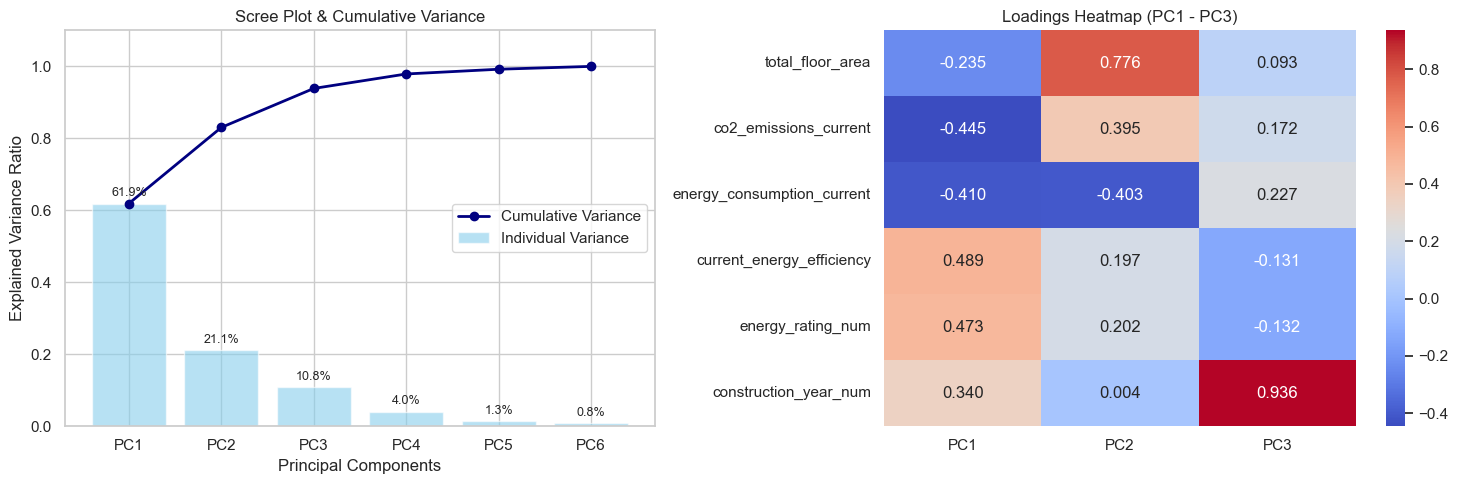

In [7]:
# ==============================================================================
# 6. VISUALIZATION GENERATION
# ==============================================================================
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot (Method 1)
pcs = [f'PC{i+1}' for i in range(len(num_vars))]
exp_var = pca_num.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

axes[0].plot(
    pcs,
    cum_var,
    marker='o',
    color='navy',
    linewidth=2,
    label='Cumulative Variance',
)
axes[0].bar(
    pcs, exp_var, alpha=0.6, color='skyblue', label='Individual Variance'
)
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_xlabel('Principal Components')
axes[0].set_title('Scree Plot & Cumulative Variance')
axes[0].legend(loc='center right')
axes[0].set_ylim(0, 1.1)

for i, val in enumerate(exp_var):
  axes[0].text(i, val + 0.02, f'{val*100:.1f}%', ha='center', fontsize=9)

# Loadings Heatmap (Method 1)
sns.heatmap(
    loadings_num[['PC1', 'PC2', 'PC3']],
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    ax=axes[1],
    cbar=True,
)
axes[1].set_title('Loadings Heatmap (PC1 - PC3)')

plt.tight_layout()
plt.show()

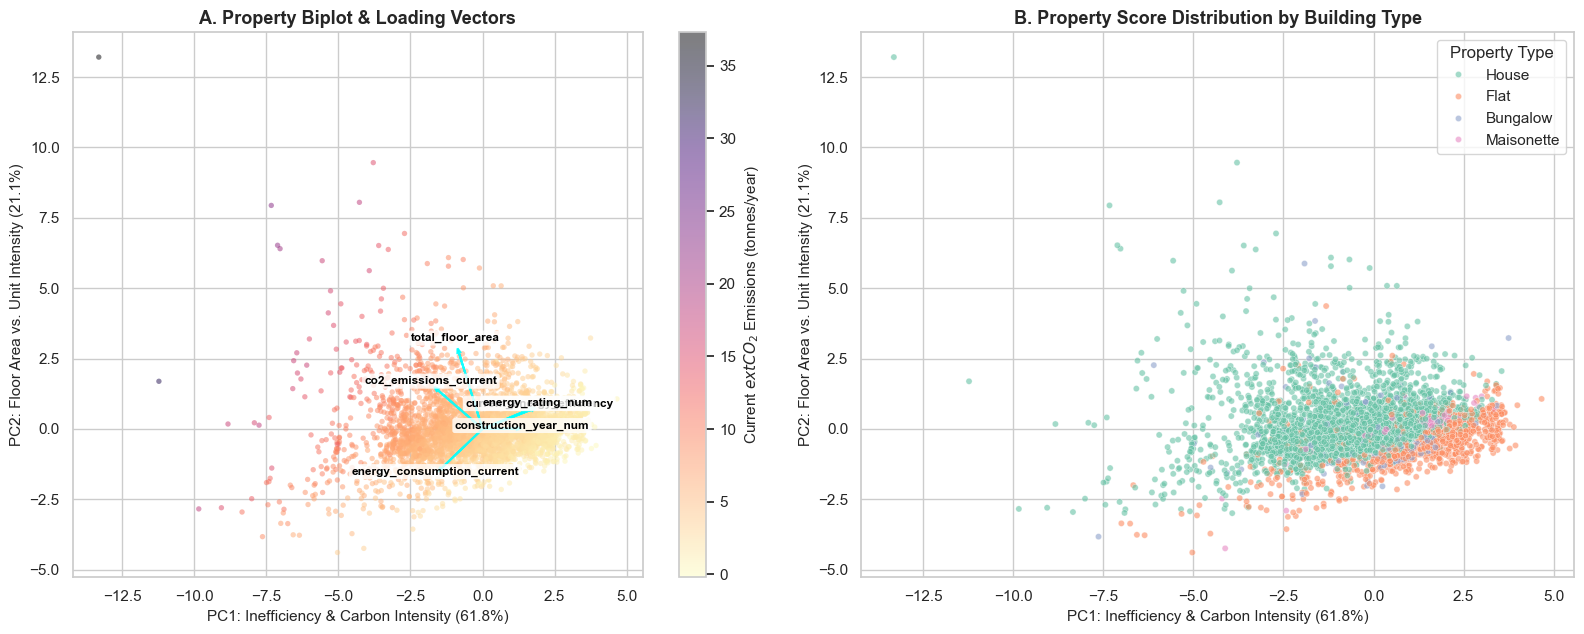

In [8]:
# ==============================================================================
# 7. Energy Inefficiency & Emissions vs Property Scale vs Energy Intensity
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA & PREPROCESS ORDINAL FEATURES
file_path = 'EPC_Sheffield_20260414-clean.csv'
df = pd.read_csv(file_path)

# Ordinal mapping dictionaries
rating_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
age_map = {
    'England and Wales: before 1900': 1890,
    'England and Wales: 1900-1929': 1915,
    'England and Wales: 1930-1949': 1940,
    'England and Wales: 1950-1966': 1958,
    'England and Wales: 1967-1975': 1971,
    'England and Wales: 1976-1982': 1979,
    'England and Wales: 1983-1990': 1986,
    'England and Wales: 1991-1995': 1993,
    'England and Wales: 1996-2002': 1999,
    'England and Wales: 2003-2006': 2004,
    'England and Wales: 2007-2011': 2009,
    'England and Wales: 2007 onwards': 2009,
    'England and Wales: 2012 onwards': 2016,
    'England and Wales: 2012-2021': 2016,
    'England and Wales: 2022 onwards': 2023,
}

df['energy_rating_num'] = df['current_energy_rating'].map(rating_map)
df['construction_year_num'] = df['construction_age_band'].map(age_map)

# Selected features for PCA decomposition
pca_vars = [
    'total_floor_area',
    'co2_emissions_current',
    'energy_consumption_current',
    'current_energy_efficiency',
    'energy_rating_num',
    'construction_year_num',
]

# Drop missing values across numeric features and metadata for plotting
df_clean = df[pca_vars + ['property_type', 'tenure']].dropna().copy()

# Clean categorical string formatting
df_clean['property_type'] = df_clean['property_type'].astype(str).str.strip()

# 2. STANDARDIZATION & PCA DECOMPOSITION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[pca_vars])

pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

df_clean['PC1'] = scores[:, 0]
df_clean['PC2'] = scores[:, 1]

# Downsample complete dataset to 5,000 points for visually clear scatter density
sample_df = df_clean.sample(n=5000, random_state=42)

# 3. PLOTTING: PC1 vs PC2 PROPERTY DISTRIBUTION & BIPLOT
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# PANEL A: Biplot with Continuous CO2 Gradient & Loading Vectors
scatter1 = axes[0].scatter(
    sample_df['PC1'],
    sample_df['PC2'],
    c=sample_df['co2_emissions_current'],
    cmap='magma_r',
    alpha=0.5,
    s=15,
    edgecolor='none',
)

cbar = fig.colorbar(scatter1, ax=axes[0])
cbar.set_label('Current $\text{CO}_2$ Emissions (tonnes/year)', fontsize=11)

# Plot loading vector trajectories
loadings = pca.components_.T
scale = 3.5  # Vector scaling multiplier for overlay visibility

for i, var in enumerate(pca_vars):
  axes[0].arrow(
      0,
      0,
      loadings[i, 0] * scale,
      loadings[i, 1] * scale,
      color='cyan',
      alpha=0.9,
      head_width=0.1,
      linewidth=1.5,
  )
  axes[0].text(
      loadings[i, 0] * scale * 1.15,
      loadings[i, 1] * scale * 1.15,
      var,
      color='black',
      fontsize=8.5,
      weight='bold',
      ha='center',
      bbox=dict(
          boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'
      ),
  )

axes[0].set_xlabel(
    f'PC1: Inefficiency & Carbon Intensity'
    f' ({pca.explained_variance_ratio_[0]*100:.1f}%)',
    fontsize=11,
)
axes[0].set_ylabel(
    f'PC2: Floor Area vs. Unit Intensity'
    f' ({pca.explained_variance_ratio_[1]*100:.1f}%)',
    fontsize=11,
)
axes[0].set_title(
    'A. Property Biplot & Loading Vectors', fontsize=13, weight='bold'
)

# PANEL B: Categorical Property Type Clusters on PC1 vs PC2
sns.scatterplot(
    data=sample_df,
    x='PC1',
    y='PC2',
    hue='property_type',
    alpha=0.6,
    s=20,
    ax=axes[1],
    palette='Set2',
)

axes[1].set_xlabel(
    f'PC1: Inefficiency & Carbon Intensity'
    f' ({pca.explained_variance_ratio_[0]*100:.1f}%)',
    fontsize=11,
)
axes[1].set_ylabel(
    f'PC2: Floor Area vs. Unit Intensity'
    f' ({pca.explained_variance_ratio_[1]*100:.1f}%)',
    fontsize=11,
)
axes[1].set_title(
    'B. Property Score Distribution by Building Type',
    fontsize=13,
    weight='bold',
)
axes[1].legend(title='Property Type', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()